In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import * 

# Load Data

In [36]:
dataFEATURES = pd.read_csv('circuits_data414820.csv')
print(dataFEATURES.shape)

C:\Users\aadik\AppData\Local\Temp\ipykernel_17680\2681470576.py:1: DtypeWarning: Columns (3,5,53) have mixed types. Specify dtype option on import or set low_memory=False.
  dataFEATURES = pd.read_csv('circuits_data414820.csv')


(414820, 121)


# Find columns to drop (bad data columns)

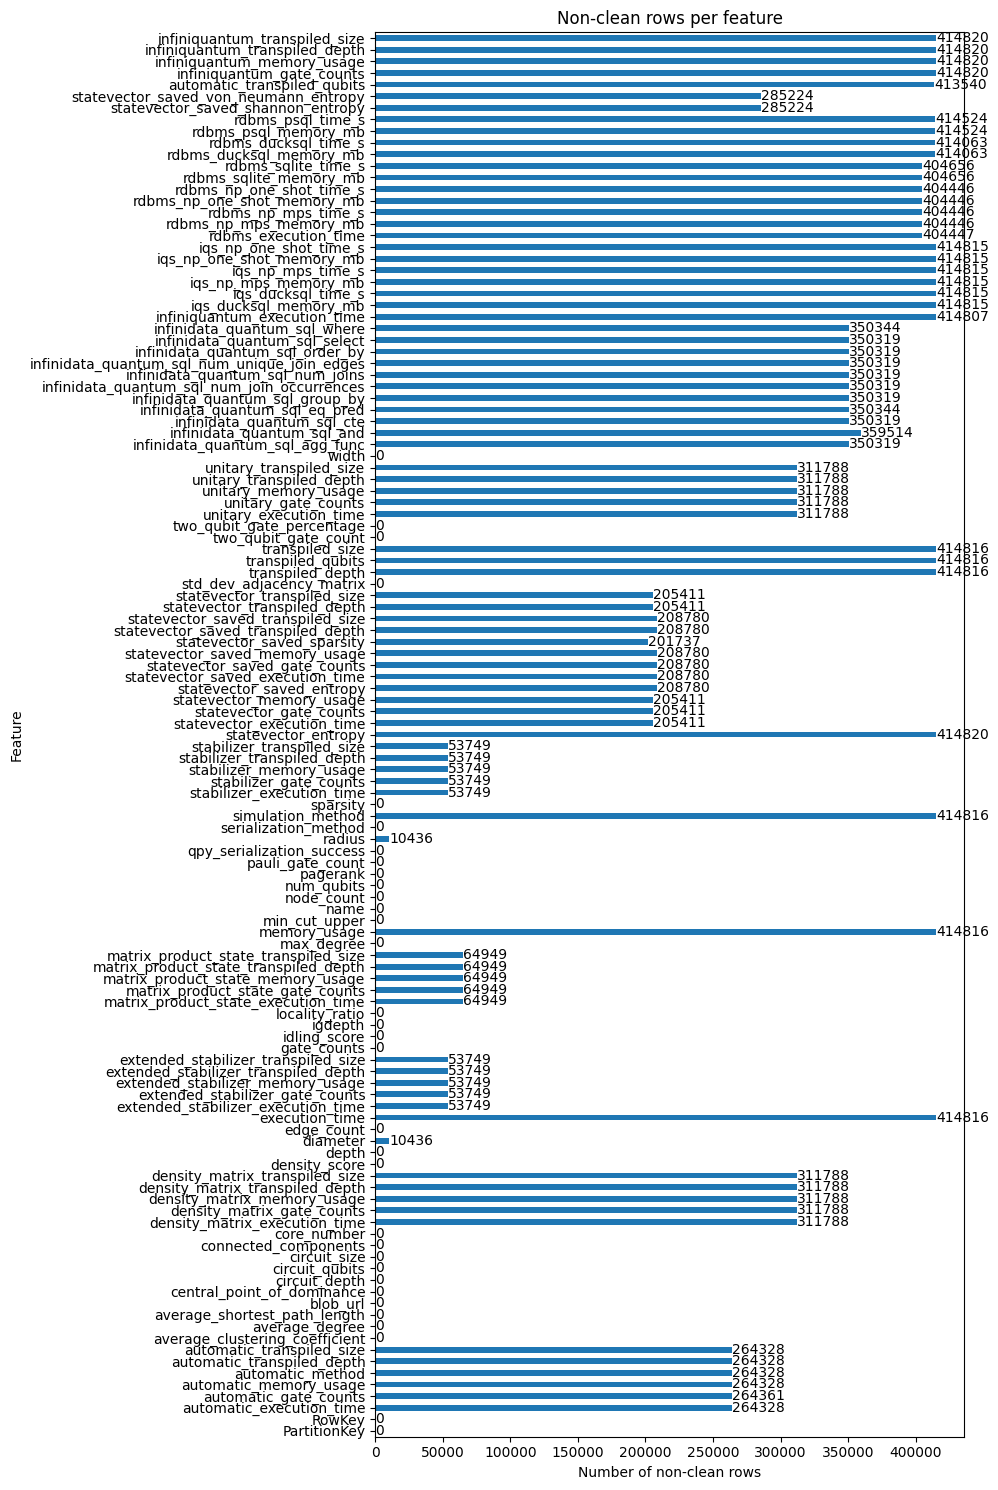

In [37]:
# dirty_counts = data.isna().sum()
dirty_counts = (
    dataFEATURES.replace(r"^\s*$", pd.NA, regex=True)
        .isna()
        .sum()
)

import matplotlib.pyplot as plt

ax = dirty_counts.plot(kind="barh", figsize=(10, 15))

for i, v in enumerate(dirty_counts):
    ax.text(v, i, str(v), va="center", ha="left")

plt.xlabel("Number of non-clean rows")
plt.ylabel("Feature")
plt.title("Non-clean rows per feature")
plt.tight_layout()
plt.show()



In [38]:
DROP_COLS = [
    # ALMOST ALWAYS 1
    "connected_components",

    # WRONG FEATURES AND MANY MISSING VALUES
    "pagerank",
    "core_number",
    "sparsity",
    "memory_usage",
    "execution_time",
    "simulation_method",
    "automatic_transpiled_qubits",
    "transpiled_size",
    "transpiled_depth",
    "transpiled_qubits",
    "statevector_entropy",

    # REDUNDANT FEATURES CORRELATED WITH OTHERS
    "circuit_depth",
    "igdepth",
    "node_count",
    "circuit_qubits",

    # OLD RDBMS WRONG COLUMNS
    'iqs_ducksql_memory_mb',
    'iqs_ducksql_time_s',
    'iqs_np_mps_memory_mb',
    'iqs_np_mps_time_s',
    'iqs_np_one_shot_memory_mb',
    'iqs_np_one_shot_time_s',

    # OLD SHANNON ENTROPY
    # "statevector_saved_entropy",
]


dataFEATURES = dataFEATURES.drop(columns=DROP_COLS)

# Clean and Split into Tables and Save Schema

In [39]:
import pandas as pd
from pathlib import Path

# -------------------------
# Start from features dataframe
# -------------------------
df = dataFEATURES.copy(deep=True)

out_dir = Path("clean_tables")
out_dir.mkdir(exist_ok=True)

KEY = "RowKey"

# -------------------------
# Qiskit simulation columns
# -------------------------
QISKIT_METHODS = [
    "statevector_saved", "statevector", "stabilizer", "density_matrix",
    "matrix_product_state", "extended_stabilizer", "unitary", "automatic"
]

QISKIT_SUFFIXES = [
    "transpiled_size",
    "transpiled_depth",
    "memory_usage",
    "execution_time",
    "gate_counts",
]

QISKIT_COLUMNS = [
    f"{m}_{s}" for m in QISKIT_METHODS for s in QISKIT_SUFFIXES
]

# -------------------------
# RDBMS simulation columns (programmatic)
# -------------------------
RDBMS_ENGINES = ["ducksql", "np_mps", "np_one_shot", "sqlite", "psql"]
RDBMS_METRICS = ["memory_mb", "time_s"]

RDBMS_COLUMNS = (
    ["infiniquantum_execution_time",
     "rdbms_execution_time",
     "infiniquantum_gate_counts",
     "infiniquantum_memory_usage",
     "infiniquantum_transpiled_depth",
     "infiniquantum_transpiled_size"]
    +
    [
        f"rdbms_{engine}_{metric}"
        for engine in RDBMS_ENGINES
        for metric in RDBMS_METRICS
    ]
)

# -------------------------
# SQL metrics
# -------------------------
SQL_COLUMNS = [
    'infinidata_quantum_sql_agg_func',
    'infinidata_quantum_sql_and',
    'infinidata_quantum_sql_cte',
    'infinidata_quantum_sql_eq_pred',
    'infinidata_quantum_sql_group_by',
    'infinidata_quantum_sql_num_join_occurrences',
    'infinidata_quantum_sql_num_joins',
    'infinidata_quantum_sql_num_unique_join_edges',
    'infinidata_quantum_sql_order_by',
    'infinidata_quantum_sql_select',
    'infinidata_quantum_sql_where'
]

# -------------------------
# Helper
# -------------------------
def save_clean(df_sub, name, require_any=False):
    cols = df_sub.columns.difference([KEY])
    if require_any:
        df_sub = df_sub.dropna(how="all", subset=cols)
    else:
        df_sub = df_sub.dropna()
    df_sub.to_csv(out_dir / name, index=False)

# -------------------------
# Simulation tables
# -------------------------
save_clean(
    df[[KEY] + QISKIT_COLUMNS],
    "qiskit_simulation.csv",
    require_any=True
)

save_clean(
    df[[KEY] + RDBMS_COLUMNS],
    "rdbms_simulation.csv",
    require_any=True
)

# -------------------------
# Merge old entropy into shannon entropy
# -------------------------
OLD_ENTROPY = "statevector_saved_entropy"
NEW_ENTROPY = "statevector_saved_shannon_entropy"

if OLD_ENTROPY in df.columns:
    # Fill shannon_entropy with old entropy where it's missing
    df[NEW_ENTROPY] = df[NEW_ENTROPY].combine_first(df[OLD_ENTROPY])


# -------------------------
# Metrics tables
# -------------------------
TABLE_SPECS = {
    "sql_metrics.csv": (
        SQL_COLUMNS,
        {
            'infinidata_quantum_sql_agg_func': 'num_agg_funcs',
            'infinidata_quantum_sql_and': 'num_and_clauses',
            'infinidata_quantum_sql_eq_pred': 'num_eq_predicates',
            'infinidata_quantum_sql_num_join_occurrences': 'num_join_occurrences',
            'infinidata_quantum_sql_num_unique_join_edges': 'num_unique_join_edges',
            'infinidata_quantum_sql_order_by': 'num_order_bys',
            'infinidata_quantum_sql_select': 'num_select_columns',
            'infinidata_quantum_sql_where': 'num_where_clauses',
            'infinidata_quantum_sql_num_joins': 'num_joins',
            'infinidata_quantum_sql_group_by': 'num_group_bys',
            'infinidata_quantum_sql_cte': 'num_subqueries_with'
        }
    ),
    "graph_metrics.csv": (
        [
            "edge_count", "max_degree", "min_cut_upper",
            "diameter", "radius", "average_degree",
            "average_clustering_coefficient",
            "average_shortest_path_length",
            "central_point_of_dominance",
            "std_dev_adjacency_matrix"
        ],
        None
    ),
    "static_metrics.csv": (
        [
            "num_qubits", "width", "depth", "circuit_size",
            "pauli_gate_count", "two_qubit_gate_count",
            "two_qubit_gate_percentage", "locality_ratio",
            "idling_score", "density_score", "gate_counts"
        ],
        None
    ),
    "dynamic_metrics.csv": (
        [
            # "statevector_saved_entropy",
            "statevector_saved_sparsity",
            "statevector_saved_shannon_entropy",
            "statevector_saved_von_neumann_entropy",
        ],
        None
    ),
}

for fname, (cols, rename_map) in TABLE_SPECS.items():
    sub = df[[KEY] + cols]
    if rename_map:
        sub = sub.rename(columns=rename_map)
    if "dynamic" in fname: save_clean(sub, fname, require_any=True)
    else: save_clean(sub, fname, require_any=False)
    # save_clean(sub, fname, require_any=False)

# -------------------------
# Metadata tables
# -------------------------
save_clean(
    df[[KEY, "PartitionKey", "blob_url"]],
    "azure_info.csv"
)

save_clean(
    df[[KEY, "name", "serialization_method", "qpy_serialization_success"]],
    "inferq_circuits.csv"
)

print(f"All clean tables saved to: {out_dir.resolve()}")


All clean tables saved to: C:\Users\aadik\InferQ\analysis\clean_tables


# Load Tables

In [40]:
import pandas as pd
from pathlib import Path

# Directory where clean tables were saved
out_dir = Path("clean_tables")

# Tables to load (updated names)
tables = {
    "azure_info": "azure_info.csv",
    "inferq_circuits": "inferq_circuits.csv",
    "graph_metrics": "graph_metrics.csv",
    "static_metrics": "static_metrics.csv",
    "dynamic_metrics": "dynamic_metrics.csv",
    "sql_metrics": "sql_metrics.csv",
    "qiskit_simulation": "qiskit_simulation.csv",
    "rdbms_simulation": "rdbms_simulation.csv",
}

# Load and count rows
row_counts = []

for name, fname in tables.items():
    df = pd.read_csv(out_dir / fname)
    row_counts.append({
        "table": name,
        "rows": len(df)
    })

# Display results
counts_df = (
    pd.DataFrame(row_counts)
    .sort_values("table")
    .reset_index(drop=True)
)

counts_df


C:\Users\aadik\AppData\Local\Temp\ipykernel_17680\2431500050.py:23: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(out_dir / fname)


,table,rows
0,azure_info,414820
1,dynamic_metrics,213083
2,graph_metrics,404384
3,inferq_circuits,414820
4,qiskit_simulation,361104
5,rdbms_simulation,10374
6,sql_metrics,55306
7,static_metrics,414820


In [41]:
# # Entropy SANITY CHECK:
# dynamic_df = pd.read_csv(out_dir / "dynamic_metrics.csv")
# # Let us find out how many times statevector_saved_shannon entropy is equal to statevector_saved_entropy
# num_equal = (np.isclose(dynamic_df["statevector_saved_shannon_entropy"], dynamic_df["statevector_saved_entropy"])).sum()
# num_total = len(dynamic_df)
# print(f"Number of equal entries: {num_equal} out of {num_total}")
# print(f"Proportion of equal entries: {num_equal / num_total:.4f}")

In [42]:
import pandas as pd
from pathlib import Path

base = Path("clean_tables")

def print_schema(df, name):
    print(f"\nSchema for {name}")
    print("=" * (len(name) + 11))
    for col in df.columns:
        print(f"{col:<50} {df[col].dtype}")

for name, fname in tables.items():
    df = pd.read_csv(base / fname)
    print_schema(df, name)



Schema for azure_info
RowKey                                             object
PartitionKey                                       object
blob_url                                           object

Schema for inferq_circuits
RowKey                                             object
name                                               object
serialization_method                               object
qpy_serialization_success                          bool

Schema for graph_metrics
RowKey                                             object
edge_count                                         int64
max_degree                                         int64
min_cut_upper                                      int64
diameter                                           float64
radius                                             float64
average_degree                                     float64
average_clustering_coefficient                     float64
average_shortest_path_length                       flo

C:\Users\aadik\AppData\Local\Temp\ipykernel_17680\3037677464.py:13: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(base / fname)



Schema for qiskit_simulation
RowKey                                             object
statevector_saved_transpiled_size                  float64
statevector_saved_transpiled_depth                 float64
statevector_saved_memory_usage                     float64
statevector_saved_execution_time                   float64
statevector_saved_gate_counts                      object
statevector_transpiled_size                        float64
statevector_transpiled_depth                       float64
statevector_memory_usage                           float64
statevector_execution_time                         float64
statevector_gate_counts                            object
stabilizer_transpiled_size                         float64
stabilizer_transpiled_depth                        float64
stabilizer_memory_usage                            float64
stabilizer_execution_time                          float64
stabilizer_gate_counts                             object
density_matrix_transpiled_size

In [43]:
import pandas as pd
from pathlib import Path

# Load qiskit metrics
qiskit_df = pd.read_csv(Path("clean_tables") / "qiskit_simulation.csv")

key = "RowKey"
sim_cols = [c for c in qiskit_df.columns if c != key]

# Split columns by method
automatic_cols = [c for c in sim_cols if c.startswith("automatic_")]
non_automatic_cols = [c for c in sim_cols if not c.startswith("automatic_")]

# Boolean masks
at_least_one_sim = qiskit_df[sim_cols].notna().any(axis=1)
all_sim_worked = qiskit_df[sim_cols].notna().all(axis=1)

auto_worked = qiskit_df[automatic_cols].notna().any(axis=1)

only_auto_worked = (
    qiskit_df[automatic_cols].notna().any(axis=1)
    & qiskit_df[non_automatic_cols].isna().all(axis=1)
)

# Print results
print("At least 1 sim worked")
print(at_least_one_sim.sum())

print("\nAll sim worked:")
print(all_sim_worked.sum())

print("\nAuto worked")
print(auto_worked.sum())

print("\nOnly automatic worked:")
print(only_auto_worked.sum())


C:\Users\aadik\AppData\Local\Temp\ipykernel_17680\2549725530.py:5: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  qiskit_df = pd.read_csv(Path("clean_tables") / "qiskit_simulation.csv")


At least 1 sim worked
361104

All sim worked:
50781

Auto worked
150492

Only automatic worked:
33


In [44]:
import pandas as pd
from pathlib import Path

base = Path("clean_tables")
KEY = "RowKey"

# Load tables
dynamic_df = pd.read_csv(base / "dynamic_metrics.csv")
static_df  = pd.read_csv(base / "static_metrics.csv")
graph_df   = pd.read_csv(base / "graph_metrics.csv")
qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")

# Join cleaned feature tables
features_df = (
    dynamic_df
    .merge(static_df, on=KEY, how="inner")
    .merge(graph_df, on=KEY, how="inner")
)

# Join with Qiskit simulation
joined_df = features_df.merge(qiskit_df, on=KEY, how="inner")

print("Rows after join (Dynamic + Static + Graph + Qiskit):")
print(len(joined_df))

# Qiskit simulation columns
sim_cols = qiskit_df.columns.difference([KEY])
automatic_cols = [c for c in sim_cols if c.startswith("automatic_")]
non_automatic_cols = [c for c in sim_cols if not c.startswith("automatic_")]

# Masks (on joined set)
at_least_one_sim = joined_df[sim_cols].notna().any(axis=1)
auto_worked = joined_df[automatic_cols].notna().any(axis=1)
only_auto_worked = auto_worked & joined_df[non_automatic_cols].isna().all(axis=1)

print("\nAt least 1 simulation worked:")
print(at_least_one_sim.sum())

print("\nAutomatic worked:")
print(auto_worked.sum())

print("\nOnly automatic worked:")
print(only_auto_worked.sum())


C:\Users\aadik\AppData\Local\Temp\ipykernel_17680\1481811080.py:11: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")


Rows after join (Dynamic + Static + Graph + Qiskit):
195939

At least 1 simulation worked:
195939

Automatic worked:
93574

Only automatic worked:
7


In [45]:
import pandas as pd
from pathlib import Path

base = Path("clean_tables")
KEY = "RowKey"

# -------------------------------------------------
# Load tables
# -------------------------------------------------
sql_df    = pd.read_csv(base / "sql_metrics.csv")
rdbms_df = pd.read_csv(base / "rdbms_simulation.csv")

# -------------------------------------------------
# Join SQL features with RDBMS simulations
# -------------------------------------------------
joined_df = sql_df.merge(rdbms_df, on=KEY, how="inner")

print("Rows after join (SQL + RDBMS):")
print(len(joined_df))

# -------------------------------------------------
# RDBMS simulation columns
# -------------------------------------------------
sim_cols = rdbms_df.columns.difference([KEY])

# group by backend
RDBMS_METHODS = [
    "psql",
    "ducksql",
    "sqlite",
    "infiniquantum"
]

method_cols = {
    m: [c for c in sim_cols if m in c]
    for m in RDBMS_METHODS
}

# -------------------------------------------------
# Masks
# -------------------------------------------------
# At least one backend worked
at_least_one_sim = joined_df[sim_cols].notna().any(axis=1)

# Per-backend success
method_worked = {
    m: joined_df[cols].notna().any(axis=1)
    for m, cols in method_cols.items()
}

# Exactly one backend worked
only_one_worked = (
    pd.concat(method_worked.values(), axis=1).sum(axis=1) == 1
)

# -------------------------------------------------
# Report
# -------------------------------------------------
print("\nAt least one RDBMS simulation worked:")
print(at_least_one_sim.sum())

print("\nPer-backend success counts:")
for m, mask in method_worked.items():
    print(f"{m:15s}: {mask.sum()}")

print("\nOnly one backend worked:")
print(only_one_worked.sum())


Rows after join (SQL + RDBMS):
9028

At least one RDBMS simulation worked:
9028

Per-backend success counts:
psql           : 242
ducksql        : 605
sqlite         : 8827
infiniquantum  : 10

Only one backend worked:
8150
